Olá, Valter

Meu nome é Ramon. Fico feliz em revisar seu projeto. Ao ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###

<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um excelente trabalho. Você tem excelente lógica de programação. Desejo-lhe sucesso na jornada. Deixei duas dicas de forma mais enxuta apenas.
</div>






# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [61]:
# Importe as bibliotecas
import pandas as pd

In [62]:
# leia os conjuntos de dados em DataFrames
df_orders = pd.read_csv("/datasets/instacart_orders.csv", sep=";")
df_products = pd.read_csv("/datasets/products.csv", sep=";")
df_aisles = pd.read_csv("/datasets/aisles.csv", sep=";")
df_departments = pd.read_csv("/datasets/departments.csv", sep=";")
df_order_products = pd.read_csv("/datasets/order_products.csv", sep=";")

In [63]:
# imprima as informações sobre o DataFrame
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [64]:
# imprima as informações sobre o DataFrame
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [65]:
# imprima as informações sobre o DataFrame
df_aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [66]:
# imprima as informações sobre o DataFrame
df_departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [67]:
# imprima as informações sobre o DataFrame
df_order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados
- Existem colunas com valores nulos

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados
-

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [68]:
# Verificar se há pedidos duplicados
df_orders.duplicated().sum()

15

Há linhas duplicadas? Se sim, o que elas têm em comum?

In [69]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
df_orders[df_orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


O que esse resultado quer dizer?
-Todos os duplicados são quarta-feira , as 2 horas da manha.

In [70]:
# Remova pedidos duplicados
df_orders = df_orders.drop_duplicates()

In [71]:
# Verifique as linhas duplicadas mais uma vez
df_orders.duplicated().sum()

0

In [72]:
# Verifique novamente apenas os IDs de pedidos duplicados
df_orders.duplicated(subset=["order_id"]).sum()

0



Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `products`

In [73]:
# Verifique se há linhas completamente duplicadas
df_products.duplicated().sum()

0

In [74]:
# Verifique apenas IDs dos produtos duplicados
df_products.duplicated(subset=["product_id"]).sum()

0

In [75]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
df_products["product_name"]=df_products["product_name"].str.lower()
df_products.duplicated(subset=["product_name"]).sum()

1361

In [76]:
# Verifique os nomes de produtos duplicados que não estão faltando
df_products[df_products["product_name"].notna()].duplicated(subset=["product_name"]).sum()

104

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `departments`

In [77]:
# Verifique se há linhas completamente duplicadas
df_departments.duplicated().sum()

0

In [78]:
# Verifique apenas se há IDs dos produtos duplicados
df_departments.duplicated(subset=["department_id"]).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `aisles`

In [79]:
# Verifique se há linhas completamente duplicadas
df_aisles.duplicated().sum()

0

In [80]:
# Verifique apenas se há IDs dos produtos duplicados
df_aisles.duplicated(subset=["aisle_id"]).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `order_products`

In [81]:
# Verifique se há linhas completamente 
df_order_products.duplicated().sum()

0

In [82]:
# Verifique mais uma vez se há outros casos complicados de duplicados
df_order_products.duplicated(subset=["order_id", "product_id"]).sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [83]:
# Encontre valores ausentes na coluna 'product_name'
df_products["product_name"].isna().sum()

1258

Descreva brevemente suas conclusões.

In [84]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
df_products[df_products["product_name"].isna()]["aisle_id"].unique()

array([100])

Descreva brevemente suas conclusões.

In [85]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
df_products[df_products["product_name"].isna()]["department_id"].unique()

array([21])

Descreva brevemente suas conclusões.

In [86]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
display(df_aisles[df_aisles["aisle_id"]==100])
display(df_departments[df_departments["department_id"]==21])

,aisle_id,aisle
99,100,missing


,department_id,department
20,21,missing


Descreva brevemente suas conclusões.

In [87]:
# Preencha nomes de produtos ausentes com 'Unknown'
df_products["product_name"] = df_products["product_name"].fillna("Unknown")
df_products["product_name"].isna().sum()

0

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `orders`

In [88]:
# Encontre os valores ausentes
df_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [89]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
df_orders[df_orders["days_since_prior_order"].isna()]["order_number"].unique()

array([1])

Descreva brevemente suas conclusões e o que você fez com elas.

### DataFrame `order_products`

In [90]:
# Encontre os valores ausentes
df_order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [91]:
# Quais são os valores mínimo e máximo dessa coluna?
df_order_products["add_to_cart_order"].min(), df_order_products["add_to_cart_order"].max()

(1.0, 64.0)

Descreva brevemente suas conclusões.

In [92]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
ids_missing = df_order_products[df_order_products["add_to_cart_order"].isna()]["order_id"].drop_duplicates()
ids_missing[:5]

737      2449164
9926     1968313
14394    2926893
16418    1717990
30114    1959075
Name: order_id, dtype: int64

In [93]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
# Agrupe os pedidos com dados ausentes por ID de pedido
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
df_order_products[df_order_products["order_id"].isin(ids_missing)].groupby("order_id")["product_id"].count().min()

65

Descreva brevemente suas conclusões.

In [94]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
df_order_products["add_to_cart_order"]=df_order_products["add_to_cart_order"].fillna(999).astype(int)

Descreva brevemente suas conclusões e o que você fez com elas.

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [95]:
print(sorted(df_orders["order_hour_of_day"].unique()))
len(df_orders["order_hour_of_day"].unique())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


24

In [96]:
print(sorted(df_orders["order_dow"].unique()))
len(df_orders["order_dow"].unique())

[0, 1, 2, 3, 4, 5, 6]


7

Escreva suas conclusões aqui

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

<AxesSubplot:xlabel='order_hour_of_day'>

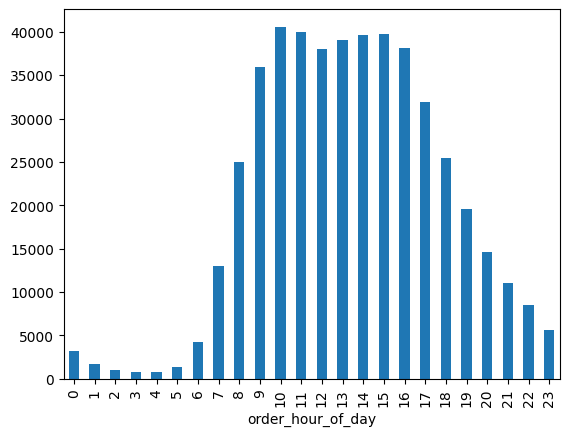

In [97]:
df_orders.groupby("order_hour_of_day")["order_id"].count().plot.bar()

Escreva suas conclusões aqui

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

<AxesSubplot:xlabel='order_dow'>

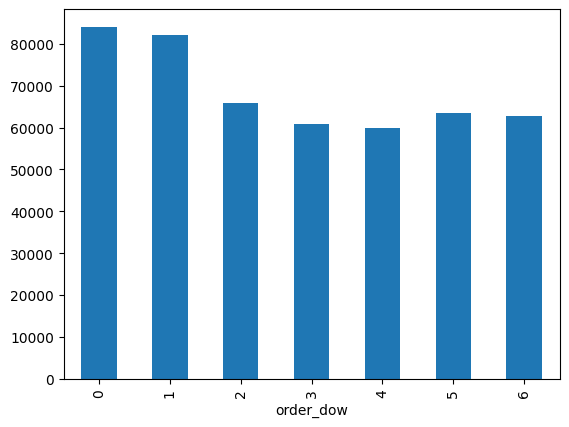

In [98]:
df_orders.groupby("order_dow")["order_id"].count().plot.bar()

Escreva suas conclusões aqui

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui

<AxesSubplot:ylabel='Frequency'>

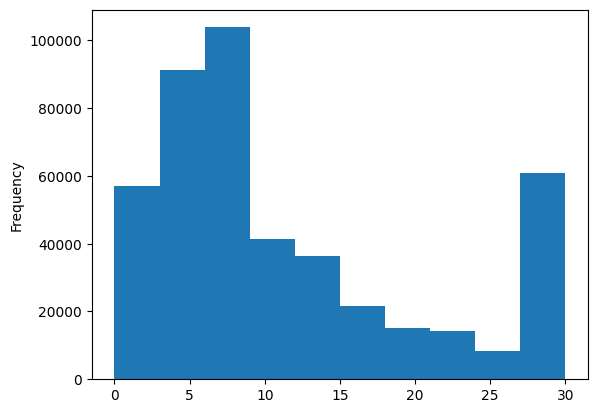

In [99]:
df_orders["days_since_prior_order"].plot.hist()

# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [100]:
import matplotlib.pyplot as plt

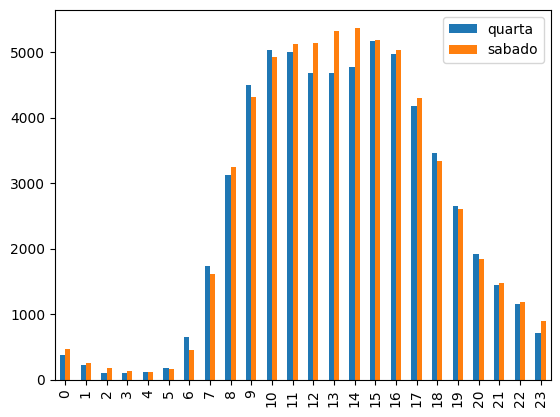

In [101]:

quarta_counts = df_orders[df_orders["order_dow"] == 3]["order_hour_of_day"].value_counts().sort_index()
sabado_counts = df_orders[df_orders["order_dow"] == 6]["order_hour_of_day"].value_counts().sort_index()
combined_df = pd.DataFrame({
    "quarta": quarta_counts,
    "sabado": sabado_counts
})

combined_df.plot.bar()
plt.show()

Escreva suas conclusões aqui

### [B2] Qual é a distribuição do número de pedidos por cliente?

<AxesSubplot:>

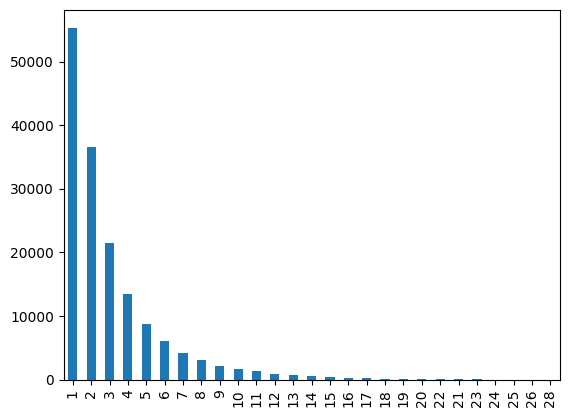

In [102]:
df_orders.groupby(["user_id"])["order_id"].count().value_counts().plot.bar()

Escreva suas conclusões aqui

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [103]:
df_ranking = df_order_products["product_id"].value_counts().head(20).reset_index()

df_ranking.columns = ["product_id", "ctn"]

df_top_products = pd.merge(df_ranking, df_products[["product_name", "product_id"]], on="product_id")

df_top_products

,product_id,ctn,product_name
0,24852,66050,banana
1,13176,53297,bag of organic bananas
2,21137,37039,organic strawberries
3,21903,33971,organic baby spinach
4,47209,29773,organic hass avocado
5,47766,24689,organic avocado
6,47626,21495,large lemon
7,16797,20018,strawberries
8,26209,19690,limes
9,27845,19600,organic whole milk


Escreva suas conclusões aqui

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

<AxesSubplot:ylabel='Frequency'>

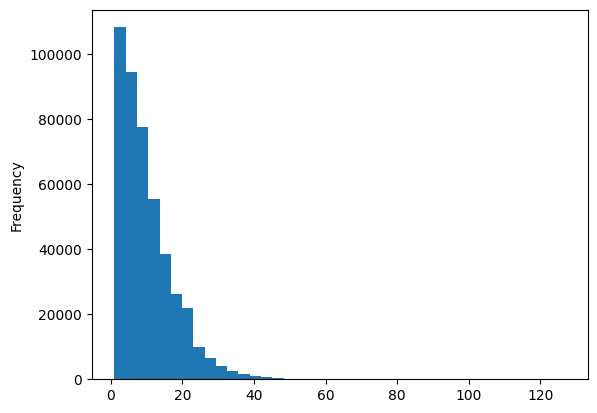

In [104]:
df_order_products.groupby(["order_id"])["product_id"].count().plot.hist(bins=40)

<AxesSubplot:>

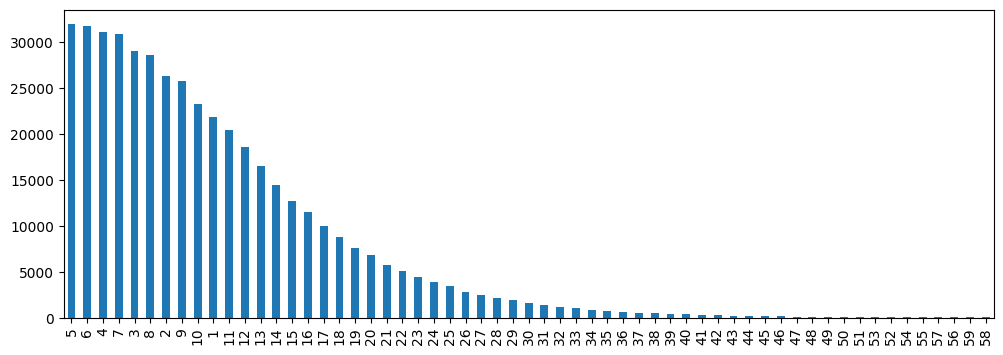

In [105]:
df_aux=df_order_products.groupby(["order_id"])["product_id"].count().value_counts()
df_aux[df_aux.index < 60].plot.bar(figsize=(12,4))

Escreva suas conclusões aqui

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [106]:
df_ranking = df_order_products[df_order_products["reordered"]==1]["product_id"].value_counts().head(20).reset_index()

df_ranking.columns = ["product_id", "ctn"]

df_top_products = pd.merge(df_ranking, df_products[["product_name", "product_id"]], on="product_id")

df_top_products

,product_id,ctn,product_name
0,24852,55763,banana
1,13176,44450,bag of organic bananas
2,21137,28639,organic strawberries
3,21903,26233,organic baby spinach
4,47209,23629,organic hass avocado
5,47766,18743,organic avocado
6,27845,16251,organic whole milk
7,47626,15044,large lemon
8,27966,14748,organic raspberries
9,16797,13945,strawberries


Escreva suas conclusões aqui

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [107]:
recompras = df_order_products.groupby("product_id")["reordered"].sum()
total_pedidos = df_order_products["product_id"].value_counts()
parcela_repetidos = (recompras / total_pedidos).reset_index()
parcela_repetidos.columns = ["product_id", "reorder_rate"]
df_resultado = pd.merge(parcela_repetidos, df_products[["product_id", "product_name"]], on="product_id")
df_resultado.sort_values(by="reorder_rate", ascending=False).head(10)

,product_id,reorder_rate,product_name
13453,14721,1.0,bone strength take care
19195,20949,1.0,vanilla sandwich cookies
6136,6723,1.0,palmiers- petite
6144,6732,1.0,naturally sparkling mineral water
41319,45088,1.0,california dill pollen & garlic goat cheese & ...
41310,45078,1.0,pomegranatea
19258,21016,1.0,parchment lined 8 in x 3.75 in x 2.5 in pans
19248,21005,1.0,peanut butter pie ice cream
32273,35192,1.0,chocolate soy milk singles
32277,35197,1.0,mocha chocolate chip organic non-dairy frozen...



<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Dica de forma mais eficiente:
</div>


In [ ]:
# df_merge = order_products.merge(products)
# reorder_rate = df_merge.groupby(['product_id', 'product_name'])['reordered'].mean()
# reorder_rate

Escreva suas conclusões aqui

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [108]:
df_merged = pd.merge(df_order_products, df_orders[["order_id", "user_id"]], on="order_id")
total_itens = df_merged.groupby("user_id")["product_id"].count()
recompras   = df_merged.groupby("user_id")["reordered"].sum()
proporcao_repetidos = (recompras / total_itens).reset_index()
proporcao_repetidos.columns = ["user_id", "reorder_rate"]
proporcao_repetidos.sort_values(by="reorder_rate", ascending=False).head(10)

,user_id,reorder_rate
99672,137587,1.0
125732,173474,1.0
10138,13918,1.0
45067,62300,1.0
45074,62307,1.0
69811,96301,1.0
45076,62312,1.0
35222,48616,1.0
45079,62316,1.0
138633,191162,1.0


Escreva suas conclusões aqui


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Dica de forma mais eficiente:
</div>


In [ ]:
# df_merge = order_products.merge(orders)
# reorder_pct = df_merge.groupby('user_id')['reordered'].mean()
# reorder_pct

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [109]:
primeiros_itens = df_order_products[df_order_products["add_to_cart_order"] == 1]
ranking_primeiros = primeiros_itens["product_id"].value_counts().head(20).reset_index()
ranking_primeiros.columns = ["product_id", "first_add_count"]
top_itens_primeiros = pd.merge(ranking_primeiros, df_products[["product_id", "product_name"]], on="product_id")
top_itens_primeiros

,product_id,first_add_count,product_name
0,24852,15562,banana
1,13176,11026,bag of organic bananas
2,27845,4363,organic whole milk
3,21137,3946,organic strawberries
4,47209,3390,organic hass avocado
5,21903,3336,organic baby spinach
6,47766,3044,organic avocado
7,19660,2336,spring water
8,16797,2308,strawberries
9,27966,2024,organic raspberries


Escreva suas conclusões aqui

# Conclusão geral do projeto:

Neste projeto, realizamos uma análise detalhada do comportamento de compra dos usuários, com foco na repetição de pedidos e nos padrões de adição ao carrinho. As principais conclusões foram:

Produtos com maior taxa de recompra:
Identificamos os produtos com maior proporção de compras repetidas. Muitos desses itens são produtos de uso diário ou recorrente, como frutas, ovos e leite, sugerindo hábitos de consumo consistentes por parte dos clientes.

Clientes fiéis a certos produtos:
Calculamos a proporção de itens repetidos por cliente e observamos que uma parcela significativa tende a refazer os mesmos pedidos, o que pode indicar lealdade à marca ou preferência por conveniência.

Padrões de adição ao carrinho:
Também analisamos os produtos mais frequentemente adicionados como primeiro item no carrinho. Itens básicos e essenciais costumam aparecer no topo dessa lista, sugerindo que os clientes começam suas compras com produtos de alta prioridade.

Diferenças por dia da semana:
Observamos padrões diferentes de horário conforme o dia da semana. Por exemplo, aos sábados, as compras se concentram mais pela manhã, enquanto durante a semana há maior dispersão ao longo do dia.